In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Load pretrained MobileNetV2 model
model = MobileNetV2(weights='imagenet')


def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Decide step size to evenly sample frames
    if total_frames > 0:
        step = max(1, total_frames // max_frames)
    else:
        step = 1

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        count += 1

        if len(frames) >= max_frames:
            break

    cap.release()
    print("Extracted frames:", len(frames))
    return np.array(frames)


def classify_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) == 0:
        print("No frames extracted!")
        return

    # Preprocess frames
    frames = preprocess_input(frames)

    # Predict
    predictions = model.predict(frames)

    # Average predictions across frames
    avg_pred = np.mean(predictions, axis=0)

    # Decode top 5 predictions
    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    print("\nTop 5 Predictions:\n")
    for pred in top_pred[0]:
        print(pred[1], ":", round(pred[2] * 100, 2), "%")

    print("\nFinal Prediction:", top_pred[0][0][1])



video_path = "/content/real_world_demo_video.mp4"

classify_video(video_path)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracted frames: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Top 5 Predictions:

digital_clock : 63.84 %
traffic_light : 9.13 %
switch : 1.43 %
computer_keyboard : 1.32 %
matchstick : 0.85 %

Final Prediction: digital_clock


In [ ]:

frames = extract_frames("/content/real_world_demo_video.mp4")


print("Frames array shape:", frames.shape)


print("First frame shape:", frames[0].shape)


print("\nFirst frame sample pixels (5x5 region):")
print(frames[0][:5, :5, :])

Extracted frames: 20
Frames array shape: (20, 224, 224, 3)
First frame shape: (224, 224, 3)

First frame sample pixels (5x5 region):
[[[233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]
  [233 206 133]]]


Extracted frames: 20
Total frames extracted: 20

Displaying Frame 1


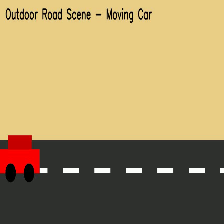


Displaying Frame 2


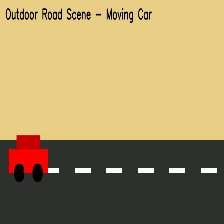


Displaying Frame 3


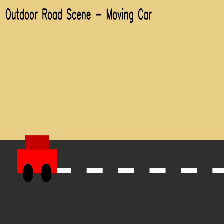


Displaying Frame 4


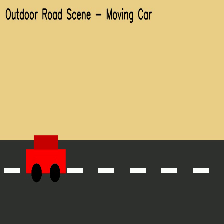


Displaying Frame 5


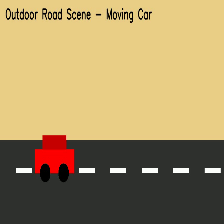


Displaying Frame 6


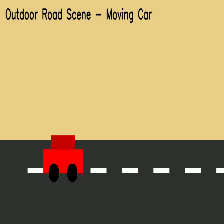


Displaying Frame 7


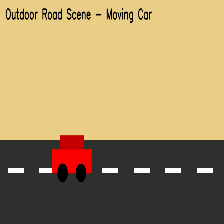


Displaying Frame 8


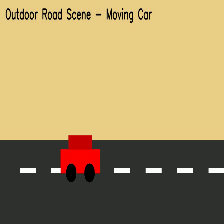


Displaying Frame 9


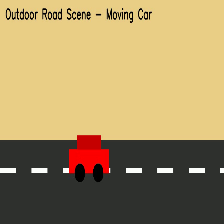


Displaying Frame 10


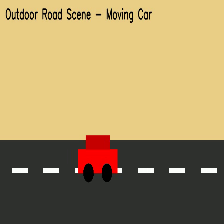


Displaying Frame 11


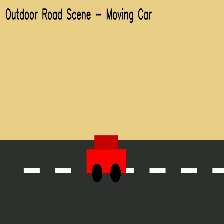


Displaying Frame 12


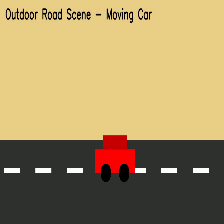


Displaying Frame 13


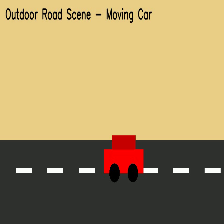


Displaying Frame 14


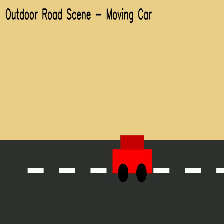


Displaying Frame 15


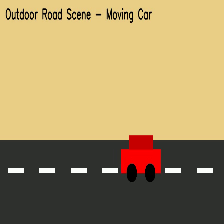


Displaying Frame 16


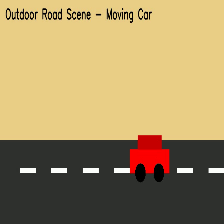


Displaying Frame 17


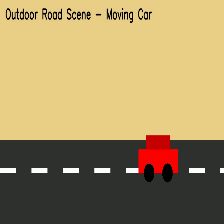


Displaying Frame 18


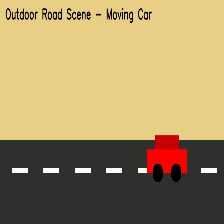


Displaying Frame 19


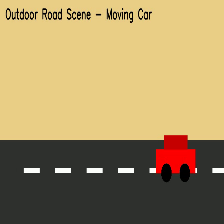


Displaying Frame 20


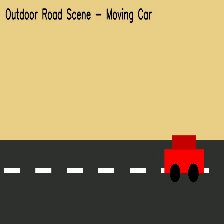

In [ ]:
from IPython.display import display
from PIL import Image

# Extract frames
frames = extract_frames("/content/real_world_demo_video.mp4")

if len(frames) == 0:
    print("No frames extracted!")
else:
    print("Total frames extracted:", len(frames))

    for i in range(len(frames)):
        print(f"\nDisplaying Frame {i+1}")
        img = Image.fromarray(frames[i])
        display(img)

Extracted frames: 20
Frame shape: (224, 224, 3)


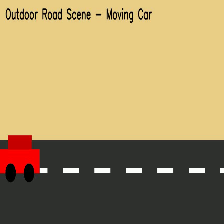

In [ ]:
from IPython.display import display
from PIL import Image


frames = extract_frames("/content/real_world_demo_video.mp4")


if len(frames) > 0:
    first_frame = frames[0]

    print("Frame shape:", first_frame.shape)


    img = Image.fromarray(first_frame)
    display(img)

else:
    print("No frames extracted!")